<a href="https://colab.research.google.com/github/habieba/KeurDeret/blob/main/forest_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forest demo: Rustico woodlot, 1935 to 2020

**MCS 3950 · Active learning, Fri Oct 2.** This notebook is a practice run of the project workflow:

1. the images live in **Google Drive**, never in git;
2. the code lives in your **team's GitHub repository**;
3. you run and edit it in **Colab**, and **File → Save a copy in GitHub** commits your changes.

The forest analysis here is deliberately crude. It is only something to run and change. Making it good is a project in itself.

**Team:** *(write your names here)*

## 1. Find the images

In Colab this mounts your Drive and looks for `My Drive/MCS3950_demo_forest/rustico`. If you haven't done it yet, open the shared Drive link, click the folder name, choose **Organize → Add shortcut → My Drive**, and rerun this cell.

Running on your own computer instead? Put the five PNGs and `info.txt` in `data/rustico/` in your clone of the repository. The template's `.gitignore` keeps them out of git.

In [7]:
import os, sys, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

YEARS = [1935, 1958, 1968, 2000, 2020]
DATA_DIR = None   # set this by hand if the search below can't find the images

if DATA_DIR is None:
    if 'google.colab' in sys.modules:
        from google.colab import drive
        drive.mount('/content/drive')
        candidates = (['/content/drive/MyDrive/MCS3950_demo_forest/rustico']
                      + sorted(glob.glob('/content/drive/MyDrive/*/MCS3950_demo_forest/rustico')))
    else:
        candidates = ['../data/rustico', 'data/rustico']
    DATA_DIR = next((c for c in candidates if os.path.isfile(os.path.join(c, '2020.png'))), None)

assert DATA_DIR, ('Images not found. In Colab: add a shortcut to MCS3950_demo_forest in My Drive. '
                  'Locally: put the PNGs in data/rustico/. Or set DATA_DIR by hand.')
print('Reading images from', DATA_DIR, '\n')
print(open(os.path.join(DATA_DIR, 'info.txt')).read())
print("habiebatou sam")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading images from /content/drive/MyDrive/Colab Notebooks/MCS3950_demo_forest/rustico 

Rustico woodlot (Prince Edward Island) - forest demo image set
Block size: 2000 m x 2000 m (2000 x 2000 pixels, 1 m per pixel).
Five images (1935, 1958, 1968, 2000, 2020) share one pixel grid: pixel (row, col) is the same ground location in every year.
Top of image is north.

1935: provincial orthomosaic (0.5 m, resampled to 1 m).
1958: provincial orthomosaic (1.16 m, resampled to 1 m). The prints carry hand-drawn forestry ink marks (e.g. near the top right).
1968: provincial orthomosaic (0.5 m, resampled to 1 m).
2000: provincial orthophoto mosaic, 1 m, greyscale (stored as RGB).
2020: provincial orthophoto, 1 m, colour.

The images line up to within a few metres on roads and field edges; treat differences smaller than about 5 m with caution.
Brightness, season and shado

In [8]:
imgs = {y: np.asarray(Image.open(f'{DATA_DIR}/{y}.png').convert('RGB')) for y in YEARS}
grey = {y: cv2.cvtColor(im, cv2.COLOR_RGB2GRAY).astype(np.float32) for y, im in imgs.items()}
for y in YEARS:
    print(y, imgs[y].shape, imgs[y].dtype, f'mean grey {grey[y].mean():.0f}')

1935 (2000, 2000, 3) uint8 mean grey 102
1958 (2000, 2000, 3) uint8 mean grey 118
1968 (2000, 2000, 3) uint8 mean grey 145
2000 (2000, 2000, 3) uint8 mean grey 137
2020 (2000, 2000, 3) uint8 mean grey 112


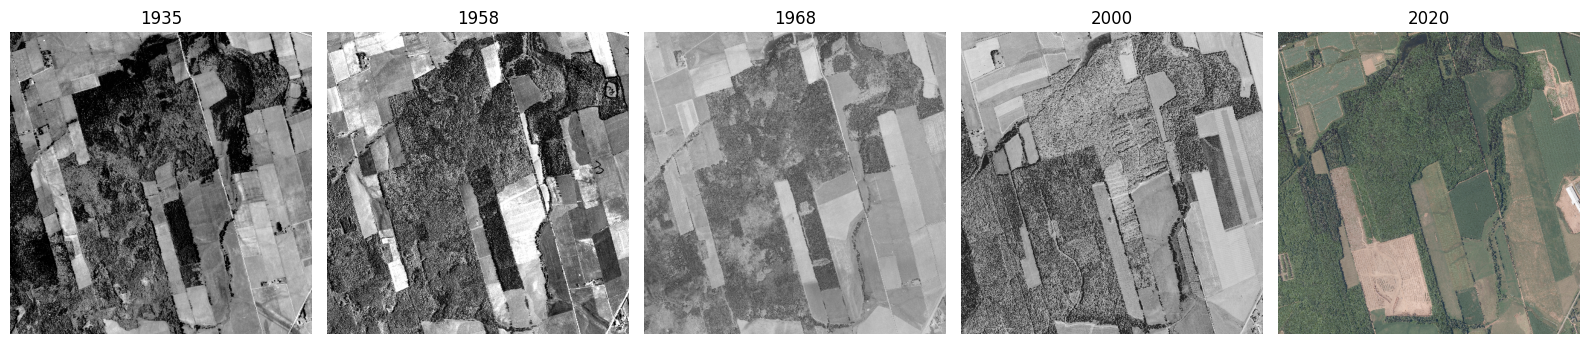

In [3]:
def show_row(images, titles, cmap=None, step=4):
    """Show images side by side. step=4 draws every 4th pixel, which keeps the
    saved notebook small enough to commit."""
    fig, axs = plt.subplots(1, len(images), figsize=(3.2 * len(images), 3.5))
    for ax, im, t in zip(np.atleast_1d(axs), images, titles):
        ax.imshow(im[::step, ::step], cmap=cmap, vmin=0 if cmap else None, vmax=1 if cmap else None)
        ax.set_title(str(t)); ax.axis('off')
    plt.tight_layout(); plt.show()

show_row([imgs[y] for y in YEARS], YEARS)

## 2. A crude forest mask

In these images, woodland is **dark** (canopy and its shadows) and **rough** (individual crowns), while fields are bright and smooth. In a `WINDOW × WINDOW` neighbourhood around every pixel we compute two numbers:

- **tone:** the local mean (a box filter, as in L3);
- **texture:** the local standard deviation.

Otsu's method (L5) picks a threshold for each year separately, because film tone differs from year to year. A morphological opening and closing (AL3) then tidies the mask.

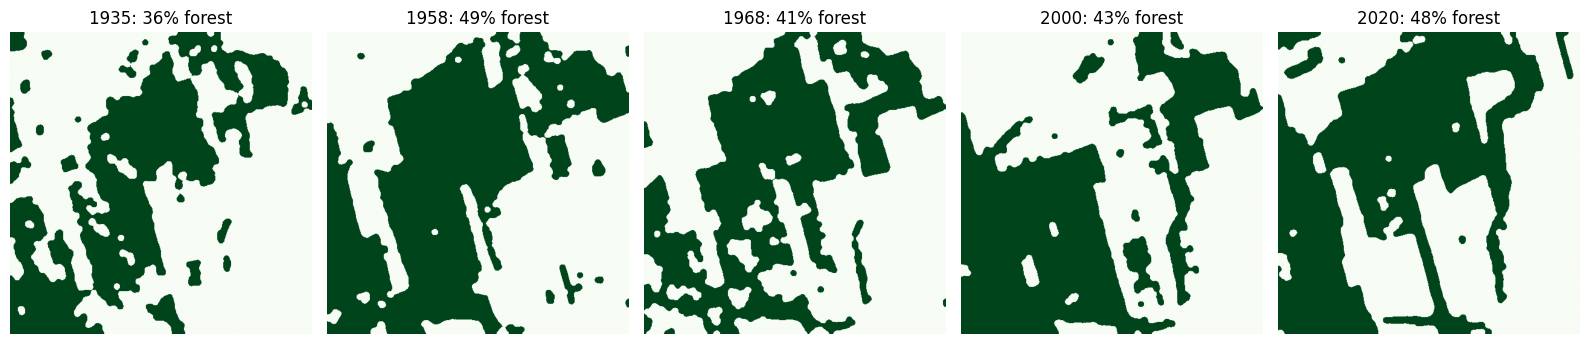

In [21]:
WINDOW =11      # neighbourhood size in pixels (1 px = 1 m)
USE_TONE = True      # forest is darker than its surroundings
USE_TEXTURE = True   # forest is rougher than fields

def local_mean_std(g, k):
    m = cv2.blur(g, (k, k))
    sd = np.sqrt(np.maximum(cv2.blur(g * g, (k, k)) - m * m, 0))
    return m, sd

def otsu(values):
    v = np.clip(values, 0, 255).astype(np.uint8)
    t, _ = cv2.threshold(v, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return t

def forest_mask(g, k=WINDOW):
    m, sd = local_mean_std(g, k)
    mask = np.ones(g.shape, bool)
    if USE_TONE:
        mask &= m < otsu(m)
    if USE_TEXTURE:
        mask &= 4 * sd > otsu(4 * sd)    # x4 stretches the std over the 0-255 range
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, se)    # remove specks
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, se)                    # fill small gaps
    return mask.astype(bool)

masks = {y: forest_mask(grey[y]) for y in YEARS}
show_row([masks[y] for y in YEARS], [f'{y}: {masks[y].mean():.0%} forest' for y in YEARS], cmap='Greens')

## 3. How much forest, and where did it change?

year   forest   area (block is 400 ha)
1935    35.7%    142.8 ha
1958    49.1%    196.2 ha
1968    40.5%    162.0 ha
2000    43.2%    172.7 ha
2020    47.8%    191.3 ha


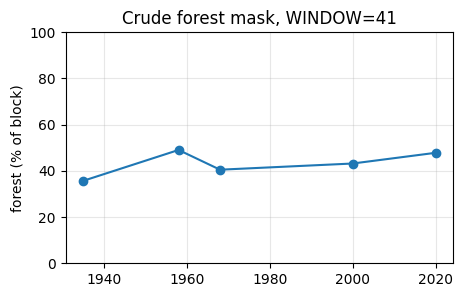

In [24]:
print('year   forest   area (block is 400 ha)')
for y in YEARS:
    print(f'{y}   {masks[y].mean():6.1%}   {masks[y].sum() / 10_000:6.1f} ha')   # 1 px = 1 m^2

plt.figure(figsize=(5, 3))
plt.plot(YEARS, [100 * masks[y].mean() for y in YEARS], 'o-')
plt.ylabel('forest (% of block)'); plt.ylim(0, 100); plt.grid(alpha=0.3)
plt.title(f'Crude forest mask, WINDOW={WINDOW}'); plt.show()

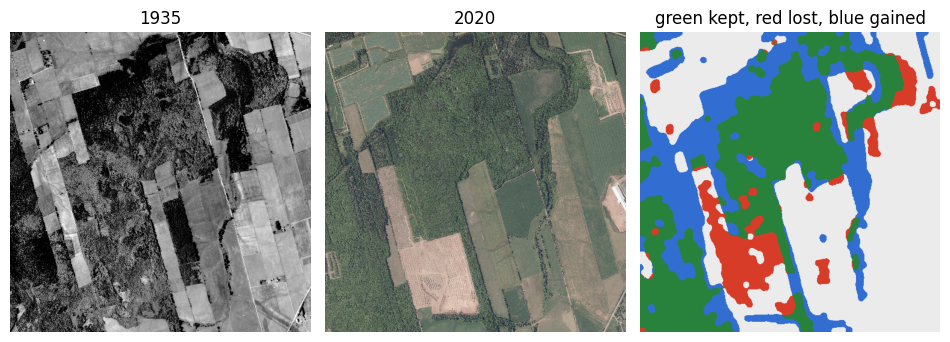

1935 -> 2020: lost 32.8 ha, gained 81.3 ha


In [27]:
A, B = 1935, 2020    # compare these two years

change = np.full(masks[A].shape + (3,), 235, np.uint8)
change[masks[A] & masks[B]]  = (40, 130, 60)    # forest in both years
change[masks[A] & ~masks[B]] = (215, 60, 40)    # forest lost
change[~masks[A] & masks[B]] = (50, 110, 210)   # forest gained

show_row([imgs[A], imgs[B], change], [A, B, 'green kept, red lost, blue gained'])
print(f'{A} -> {B}: lost {(masks[A] & ~masks[B]).sum() / 1e4:.1f} ha, '
      f'gained {(~masks[A] & masks[B]).sum() / 1e4:.1f} ha')

## 4. Your turn

Make **at least two** of these changes, then save to GitHub (below).

1. Put your names in the first cell.
2. Set `WINDOW` to 11, then 41, and rerun from section 2. Write one sentence in a new text cell: what changed, and why?
3. Change `A` and `B` to a different pair of years.
4. Set `USE_TEXTURE = False`. Which year's estimate jumps the most? Look at that year's image. *(Hint: what colour are the fields in 2020?)*
5. Add a text cell that points to **one place where the mask is clearly wrong**, and say why you think it fails there.

## 5. Save to GitHub (this is the push)

**File → Save a copy in GitHub**, then:

- **Repository:** your team's repository. **Branch:** `main`.
- **File path:** `notebooks/forest_demo_<yourname>.ipynb`. Each of you saves your own copy, so you don't overwrite each other's work and each of you has a commit under your own name.
- **Commit message:** say what you changed, e.g. `forest demo: compare WINDOW 11 vs 41`. Not `Created using Colab`.

Then open the repository on GitHub and check **Commits**: your commit should be there under your own account.

If your repository isn't in the list, tick **Include private repos**. If it's still missing, tell the instructor: the course organisation has to approve Colab once.